# **phase 1: explore data** 

In [234]:
import pandas as pd 
df = pd.read_csv("googleplaystore.csv")
df.shape

(10841, 13)

In [235]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='str')

In [236]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [237]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


# **Phase 2: Data Quality Assessment**

In this phase, we checked the quality of the dataset and identified expected issues in each column.  
No actual cleaning was performed,the focus was on detecting problems that may need attention later to handle in the next pahse.

### What was done in this phase:
- **App**: Checked for duplicates.
- **Category**: Noted invalid values or values mistakenly shifted from other columns.  
- **Rating**: Identified missing values and values outside the expected range (0–5).  
- **Reviews, Size, Installs**: Detected non-numeric or irregular formats requiring conversion later.  
- **Type, Price, Content Rating, Genres**: Found missing values, incorrectly shifted entries, and inconsistencies in format.  
- **Last Updated, Current Ver, Android Ver**: Checked for inconsistent formats, missing values, and non-standard text entries.  

this list of data issues is prepared to be addressed in **Phase 3: Data Cleaning**, ensuring a smooth cleaning process 

In [238]:
# Now, I will test each column individually to identify its issue

In [239]:
# 1. App
# str --> keep as str 
# 1181 duplicated value 
# no missing values appeared for now --> maybe misleading --> missing values can be written as "uknown" , "none" for example. 

In [240]:
# Filter rows where the 'App' column contains common missing value keywords
# no such app names found 
missing_keywords = ['unknown', 'none', 'null', 'n/a', '-', 'nan']
missing_apps = df[df['App'].str.lower().isin(missing_keywords)]
missing_apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [241]:
# count the duplicates in App column
df["App"].duplicated().sum()

np.int64(1181)

In [242]:
# now i will remove duplicates:
# 1. Sort the dataset by 'Reviews' in descending order
# This ensures that when we remove duplicates, we retain the entry with the most reviews (most popular/recent).
df.sort_values('Reviews', ascending=False, inplace=True)

# 2. Remove duplicate entries based on the 'App' name
# subset=['App']--> Check for duplicates in the 'App' column only
# keep='first': Keep the first occurrence (which corresponds to the highest reviews after sorting)
df.drop_duplicates(subset=['App'], keep='first', inplace=True)

# 3. Reset the index to be sequential
df.reset_index(drop=True, inplace=True)
len(df) # Display the new total count of rows


9660

In [243]:
# Display the count of dropped rows
10841-len(df)

1181

In [244]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9660 entries, 0 to 9659
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9660 non-null   str    
 1   Category        9660 non-null   str    
 2   Rating          8197 non-null   float64
 3   Reviews         9660 non-null   str    
 4   Size            9660 non-null   str    
 5   Installs        9660 non-null   str    
 6   Type            9659 non-null   str    
 7   Price           9660 non-null   str    
 8   Content Rating  9659 non-null   str    
 9   Genres          9660 non-null   str    
 10  Last Updated    9660 non-null   str    
 11  Current Ver     9652 non-null   str    
 12  Android Ver     9657 non-null   str    
dtypes: float64(1), str(12)
memory usage: 981.2 KB


In [245]:
# 2. Category
# main category of the app
# str --> keep as str 
# no missing values appeared 
# 1.9 --> its actually a rating value --> shifted to category col by mistake  --> (to do in phase 3)

In [246]:
# display all unique categories
# note all are acceptable except '1.9'
df["Category"].unique()

<StringArray>
[             'SPORTS',               'TOOLS',            'SHOPPING',
    'TRAVEL_AND_LOCAL',              'FAMILY',       'VIDEO_PLAYERS',
       'COMMUNICATION',              'COMICS',                'GAME',
             'MEDICAL',       'ENTERTAINMENT',   'AUTO_AND_VEHICLES',
        'PRODUCTIVITY',           'EDUCATION',              'EVENTS',
           'PARENTING',         'PHOTOGRAPHY',           'LIFESTYLE',
            'BUSINESS',             'WEATHER', 'BOOKS_AND_REFERENCE',
     'PERSONALIZATION',  'HEALTH_AND_FITNESS',  'NEWS_AND_MAGAZINES',
              'DATING',             'FINANCE',      'ART_AND_DESIGN',
              'BEAUTY',              'SOCIAL', 'MAPS_AND_NAVIGATION',
      'FOOD_AND_DRINK',  'LIBRARIES_AND_DEMO',      'HOUSE_AND_HOME',
                 '1.9']
Length: 34, dtype: str

In [247]:
# 3. Rating
# represents user score of the app (1–5) showing how much users like it.
# float               --> keep as float 
# 1463 missing values --> (to do in phase 3) 
# min = 1 , max = 19 
# mean = 4.17 , median = 4.30
# i know that rating usually is in range 0-5
# note that max = 19         --> check for rating > 5         --> no other ratings > 5
# only 1 value is found (19) --> its actually a Reviwes value --> shifted to Rating col by mistake -->  (to do in phase 3) 
df["Rating"].describe()

count    8197.000000
mean        4.174893
std         0.560928
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

In [248]:
# check for values > 5 other than 19
# no other values > 5 found 
df[df["Rating"] > 5 ]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [249]:
# 4. Reviews
# number of user reviews submitted for the app.
# str                                --> convert to int  (to do in phase 3)
# no missing values appeared for now --> maybe misleading bcz the type is str not int 
# note that out of 9660 row , 9659 is numeric , 1 value is not --> check this value
numeric_reviews =df[df["Reviews"].str.isnumeric()]
len(numeric_reviews)

9659

In [250]:
# Check for non-numeric value in the "Reviews" column
# only 1 value is found (3.0M) --> its actually a Size value --> shifted to Reviews col by mistake  -->  (to do in phase 3) 
df[df["Reviews"].str.isnumeric() == False]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [251]:
# 5. Size
# the size of the app, it could be stored in  megabytes (M), kilobytes (k)
# no missing values appeared for now --> maybe misleading bcz the type is str not float 
df["Size"].describe()

count                   9660
unique                   462
top       Varies with device
freq                    1227
Name: Size, dtype: object

In [252]:
# note the Size col contanis the value 'Varies with device'
df["Size"]

0        31M
1        91k
2        18M
3        33M
4        22M
        ... 
9655     16M
9656    8.0M
9657    2.6M
9658     11M
9659    1.6M
Name: Size, Length: 9660, dtype: str

In [253]:
# filter rows where 'Size' contains 'M' (megabytes)
has_M = df[df['Size'].str.contains('M')]
has_M.value_counts(dropna=False).sum()

np.int64(8118)

In [254]:
# filter rows where 'Size' contains 'k' (kilobytes)
has_k = df[df['Size'].str.contains('k')]
has_k.value_counts(dropna=False).sum()

np.int64(314)

In [255]:
# filter rows where 'Size' contains 'Varies with device'
has_varies_with_device=df[df['Size'].str.contains('Varies with device')]
has_varies_with_device.value_counts(dropna=False).sum()

np.int64(1227)

In [256]:
# filter all other rows (not M, k, or 'Varies with device')
# only 1 row remained --> check its value 
others=df[~df['Size'].str.contains('M') & ~df['Size'].str.contains('k') & ~df['Size'].str.contains('Varies with device') ]
others.value_counts(dropna=False).sum()

np.int64(1)

In [257]:
# check the value of the remaining row
# only 1 value is found (1,000+) --> its actually an Installs value --> shifted to Size col by mistake  -->  (to do in phase 3) 
others

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [258]:
# 6. Installs 
# the number of times each app has been installed.
# str --> convert to int -->   (to do in phase 3)
# no missing values appeared for now --> maybe misleading bcz the type is str not int
# to be able to convert to int -->  remove symbol appeared in the col ',' & '+'
# how to get sure there is no other symbols in the col ? 
# Instead of manually removing symbols like ',' or '+', we will use Regex to directly clean the column by removing any character that is not a digit.
# This ensures all non-numeric values are handled safely and consistently during conversion to integer.
df["Installs"]

0       1,000,000+
1         100,000+
2       1,000,000+
3       1,000,000+
4         500,000+
           ...    
9655          100+
9656          100+
9657          100+
9658            5+
9659           10+
Name: Installs, Length: 9660, dtype: str

In [259]:
# filter rows where 'Installs' contains no ',' or '+'
# 2 raws appeared
others=df[~df['Installs'].str.contains(',') & ~df['Installs'].str.contains('+', regex=False) ]
others.value_counts(dropna=False).sum()

np.int64(2)

In [260]:
# Free value appeared
# it appears that the value "Free" belongs to the 'Type' column 
# but has been mistakenly placed in the 'Installs' column. -->  (to do in phase 3)
others

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN
9336,Command & Conquer: Rivals,FAMILY,NaN,0,Varies with device,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device,Varies with device


In [261]:
# 7. Type
# App type based on payment (Free or Paid)
# str --> keep as str 
# 1 missing value (NaN)       --> (to do in phase 3)
# 1 inconsistant category (0) --> its actually a Price value --> shifted to Type col by mistake  --> (to do in phase 3)
df["Type"].value_counts(dropna=False)

Type
Free    8902
Paid     756
0          1
NaN        1
Name: count, dtype: int64

In [262]:
# make sure all paid apps have actual price
# no paid apps with price =0 
df[(df['Type'] == 'Paid') & (df['Price'] == 0)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [263]:
# Check for the inconsistant value in the "Types" column
# only 1 value is found (0)
df[df["Type"]=='0']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [264]:
# 8. Price
# str --> convert to float   (to do in phase 3)
# to be able to convert to int   --> we have to remove values containing currency symbols if any 
# we also found "Everyone" value --> need to be handled
df["Price"].describe()

count     9660
unique      93
top          0
freq      8903
Name: Price, dtype: object

In [265]:
# filter rows where 'Price' is numeric
# 10040 row found 
# convert without problems
numeric_prices =df[df["Price"].str.isnumeric() == True ]
numeric_prices.value_counts(dropna=False).sum()


np.int64(8903)

In [266]:
# filter rows where 'Price' is non-numeric
# 801 raw found 
# handle then convert
non_numeric_prices = df[df['Price'].str.isnumeric() == False]
non_numeric_prices.value_counts(dropna=False).sum()

np.int64(757)

In [267]:
# Check if all non-numeric prices start with '$'
# all start with '$' except 1 value 'Everyone'
# it appears that the value "Everyone" belongs to the 'Content Rating' column 
# but has been mistakenly placed in the 'Price' column.   (to do in phase 3)
non_numeric_prices[~non_numeric_prices['Price'].str.startswith('$', na=False)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [268]:
# 9. Content Rating
# str --> keep as str
# 1 missing value (NaN) --> its actually a Genres value --> shifted to Content Rating col by mistake  --> (to do in phase 3)
# categories "Adults only 18+" and "Unrated" are rare compared to other categories,
# this makes class imbalance that may prevent model learning
# so its better to combine them (to do in phase 3)
# Adults only 18+ map to --> Mature 17+  (the nearest category)
# Unrated map to         --> Everyone    (the most common category)
df["Content Rating"].value_counts(dropna=False)

Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        322
Adults only 18+       3
Unrated               2
NaN                   1
Name: count, dtype: int64

In [269]:
# 10. Genres
# genres column has inconsistent formats. Some rows have one genre like (Tools), others have multiple genres separated by ';',
# this column needs cleaning. (to do in phase 3 )
# February 11, 2018 --> its actually a Last Updatedes value --> shifted to Genres col by mistake  --> (to do in phase 3)
df["Genres"].value_counts(dropna=False)

Genres
Tools                          827
Entertainment                  561
Education                      510
Business                       420
Medical                        395
                              ... 
Role Playing;Brain Games         1
Lifestyle;Pretend Play           1
Music & Audio;Music & Video      1
Strategy;Creativity              1
Role Playing;Education           1
Name: count, Length: 120, dtype: int64

In [270]:
# look if there are other invalid values like February 11, 2018
# no otherinvalid values found
df[df['Genres'].str.contains(r'\d', na=False)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [271]:
# Filter all rows in 'Genres' that contain multiple genres separated by ';'
# Count how many times each multi-genre combination appears
# Note: The combinations "Education;Education" (50 rows) and "Educational;Education" (41 rows) are the most frequent multi-genre entries. 
# These two genre combinations are very similar and need be merged when cleaning (to do in phase 3)
double_genre_rows = df[df['Genres'].str.contains(';', na=False)]
double_genre_rows['Genres'].value_counts()

Genres
Educational;Education          38
Education;Education            36
Casual;Pretend Play            25
Puzzle;Brain Games             18
Education;Pretend Play         17
                               ..
Role Playing;Brain Games        1
Lifestyle;Pretend Play          1
Music & Audio;Music & Video     1
Strategy;Creativity             1
Role Playing;Education          1
Name: count, Length: 72, dtype: int64

In [272]:
# check if there is "Educational" category to map to "Education"  --> to do in phase 3
# there are 37 value with 'Educational' 
genre_Educational=df[df["Genres"] == "Educational"]
len(genre_Educational)


37

In [273]:
# 11. Last Updatedes
# str --> convert to date  (to do in phase 3)
# no missing values appeared for now --> maybe misleading bcz the type is str not date
df["Last Updated"]

0            May 23, 2018
1       December 17, 2013
2        January 22, 2018
3            June 5, 2018
4          August 6, 2018
              ...        
9655        June 17, 2016
9656        July 28, 2017
9657     December 5, 2017
9658      August 14, 2016
9659        June 14, 2018
Name: Last Updated, Length: 9660, dtype: str

In [274]:
# 12. Current Ver
# str --> keep as str
# 8 missing values appeared for now --> maybe misleading bcz the type is str not float 
df["Current Ver"]

0           6.5
1           3.2
2           1.4
3           7.1
4        1.28.1
         ...   
9655      1.0.4
9656        1.0
9657      1.1.8
9658    1.0.103
9659        5.0
Name: Current Ver, Length: 9660, dtype: str

In [275]:
# 8 missing values --> (to do in phase 3)
df["Current Ver"].isna().sum()

np.int64(8)

In [276]:
# filter rows where 'Current Ver' is pure number
# find the number of apps having the 'Current Ver' pure number = 146
pure_num=df[df["Current Ver"].str.isnumeric()]
len(pure_num)

139

In [277]:
# Identify rows in 'Current Ver' that contain only text (no digits)
# and count how many apps have such pure text version entries
pure_text = (df['Current Ver'].notna() & ~df['Current Ver'].str.contains(r'\d', regex=True))
pure_text_values = df[pure_text]['Current Ver']
pure_text_values.value_counts()

Current Ver
Varies with device            1055
Final                            2
BlueOrange                       1
App copyright                    1
newversion                       1
Natalia Studio Development       1
Human Dx                         1
Copyright                        1
HTTPs                            1
DH-Security Camera               1
Gratis                           1
Public.Heal                      1
KM                               1
opciÃ³n de cerrar                1
closed                           1
Initial                          1
MONEY                            1
Name: count, dtype: int64

In [278]:
# filter rows where 'Current Ver' contains ','
# find the number of apps having the 'Current Ver' contains ',' = 4
# fix this ',' --> '.'     to do in phase 3
has_coma =df[df['Current Ver'].str.contains(r'\,', na=False)]
has_coma.value_counts(dropna=False).sum()
has_coma

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1947,M3-X5-X6-M-İ3-İ8 RACİNG 2018,GAME,4.4,596,44M,"100,000+",Free,0,Everyone,Arcade,"February 12, 2017","1,01",4.0 and up
3417,Obbligo o Verità? PRO,GAME,NaN,4,2.9M,100+,Paid,$0.99,Teen,Board,"April 26, 2018","1,01",3.0 and up
4595,BV,COMMUNICATION,5.0,3,1.6M,100+,Free,0,Everyone,Communication,"August 4, 2016","1,01",3.0 and up
8135,C3-C4-PİCASSO-ELYSEE RACİNG,GAME,NaN,12,48M,"1,000+",Free,0,Everyone,Arcade,"February 12, 2017","1,01",4.0 and up


In [279]:
# I will extract the numeric version into a new column to create a clean feature, while keeping the original text for reference.
# This is why you will not find a purely numeric format in the original Current Ver column

In [280]:
# Android Ver
# str --> keep as str
# 3 missing values appeared for now --> maybe misleading bcz the type is str not float 
df["Android Ver"]

0         4.1 and up
1         2.2 and up
2         4.3 and up
3         5.0 and up
4         5.0 and up
            ...     
9655      4.0 and up
9656      4.0 and up
9657    4.0.3 and up
9658      4.4 and up
9659      4.0 and up
Name: Android Ver, Length: 9660, dtype: str

In [281]:
# filter rows where 'Android Ver' contains 'and up' & find their count = 9467
has_andup =df[df["Android Ver"].str.contains('and up')]
len(has_andup)


8658

In [282]:
# filter rows where 'Android Ver' contains 'Varies with device' & find their count = 1362
has_varies_with_device = df[df["Android Ver"].str.contains('Varies with device')]
len(has_varies_with_device)

990

In [283]:
# filter rows where 'Android Ver' doesnt contain neither  'Varies with device' nor 'and up' and find their count = 12 
other = df[~(df["Android Ver"].str.contains('and up')) & ~(df["Android Ver"].str.contains('Varies with device'))]
other["Android Ver"].value_counts(dropna=False)

Android Ver
NaN              3
4.0.3 - 7.1.1    2
5.0 - 8.0        2
4.1 - 7.1.1      1
2.2 - 7.1.1      1
5.0 - 6.0        1
7.0 - 7.1.1      1
5.0 - 7.1.1      1
Name: count, dtype: int64

In [284]:
# I will extract the numeric version into a new column to create a clean feature, while keeping the original text for reference.
# This is why you will not find a purely numeric format in the original Android Ver column

# **Phase 3: Data Cleaning & Transformation**

in this phase, i will perform the cleaning and transformation to fix the issues identified in Phase 2.  

**What was done:**
- **Fixed Data Types:** Converted columns like `Reviews`, `Size`, `Installs`, and `Price` from text to correct numerical formats.  
- **Handled Missing Values:** Used **KNN Imputer** for `Rating`, **Median** for `Size`, and **Simple Imputer** for categorical columns.  
- **Feature Engineering:** Created new useful columns like `Estimated_Revenue`, `Year_Released`, and `Version_Major`.

In [285]:
# During prev phase, we noticed a problem with this row
# It seems all entries in this row are shifted
# now i will fix them
df[df["Category"] == '1.9']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
4484,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [286]:
# Manually fix the row at index 4484 where values are misplaced.
# Set the correct values for each column, including handling missing or shifted entries.
df.loc[4484] = [
    "Life Made WI-Fi Touchscreen Photo Frame",
    None,      # Category
    1.9,       # Rating
    '19.0',      # Reviews
    "3.0M",    # Size
    "1,000+",  # Installs
    "Free",    # Type
    '0',         # Price
    "Everyone",# Content Rating
    None,      # Genres
    "February 11, 2018" , # Last Updated
    "1.0.19",  # Current Ver
    "4.0 and up", # Android Ver
]

In [287]:
# display the row after fixing 
df.loc[4484]

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              NaN
Rating                                                1.9
Reviews                                              19.0
Size                                                 3.0M
Installs                                           1,000+
Type                                                 Free
Price                                                   0
Content Rating                                   Everyone
Genres                                                NaN
Last Updated                            February 11, 2018
Current Ver                                        1.0.19
Android Ver                                    4.0 and up
Name: 4484, dtype: object

In [288]:
# now i will start cleaning cols

### **Step 1: Converting to Correct Data Types & Fixing Columns**

| Column        | Current Type | Correct Type | Notes                        |
|---------------|--------------|-------------|-------------------------------|
| Reviews       | str          | int       | Convert numeric text to int   |
| Size          | str          | float       | Handle "M", "k", and "Varies with device" |
| Installs      | str          | int         | Remove symbols like ',' and '+' before conversion |
| Price         | str          | float       | Remove '$' and handle 'Free' values |
| Last Updated  | str          | date        | Convert string dates to datetime format |

In [289]:
# 1. Reviews
# any value that cannot be converted will become NaN.
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df["Reviews"].dtype

dtype('float64')

In [290]:
# convert 'Reviews' col float to int 
df["Reviews"] = df["Reviews"].astype('Int64')
df["Reviews"].dtype

Int64Dtype()

In [291]:
# after converting to int --> check no nan values appeared
df['Reviews'].isna().sum()

np.int64(0)

In [292]:
# Show any Size values that don't contain 'M', 'k', or 'Varies with device'
df[~df['Size'].str.contains('M|k|Varies with device', na=False)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [293]:
# 2. size
# we cant convert to float until we deal with the values found in phase2 "M"=MegaByte , "k"=kiloByte , "Varies with device" 
# if the value has "M" remove the M 
# if the value has "k" remove the k and divide by 1024 --> we want the size unit for all values to be in M --> to convert k to M --> divide by 1024
# else (the value has "Varies with device") set it to None because there is no specific size
# as we handled all the values in the col --> the 'Size' col now is float 
def clean_size (size):
    if 'M' in size:
        return float(size.replace('M',''))
    elif 'k' in size:
        return float(size.replace('k',''))/1024 # convert to mega 
    else: # "varies with device case"
        return None

df["Size"] = df["Size"].apply(clean_size)
df["Size"].dtype

dtype('float64')

In [294]:
# note 'M' & 'k' disappeared
# NaN now represents 'Varies with device' before
df['Size']

0       31.000000
1        0.088867
2       18.000000
3       33.000000
4       22.000000
          ...    
9655    16.000000
9656     8.000000
9657     2.600000
9658    11.000000
9659     1.600000
Name: Size, Length: 9660, dtype: float64

In [295]:
# after converting to int check whether nan values appear 
# 'Size' contains 1227 with the value 'Varies with device'
#  when converting to int , these values become nan
df["Size"].isna().sum()

np.int64(1227)

In [296]:
# The above method works for converting sizes, but if there are any unexpected symbols combined with number
# (other than 'M', 'k', or "Varies with device"), they will also become NaN, which is not correct. 
# Using isna() allows us to check how many values actually became NaN and detect such issues.
# according to our code every 'Varies with device' should be converted to nan 
# from phase 2 --> count of values containing 'Varies with device' = 1695
# here check the nan values num --> = 1695
# The count of NaN matches the number of 'Varies with device' entries from Phase 2.
# so the method works as expected

In [297]:
# 3. Installs 
# we cant convert to float until we deal with the values found in phase2 containing "," , "+" 
# remove ',' & '+'
# as we handled all the values in the col --> the 'Installs' col now is float 
# finally convert to int
def clean_Installs(install):
    if ',' in install or '+' in install:
        return float(install.replace(',', '').replace('+', ''))
    else:
        return float(install)
    
df["Installs"] = df["Installs"].apply(clean_Installs)
df["Installs"] = df["Installs"].astype('Int64')

In [298]:
# note ',' & '+' disappeared
df["Installs"]

0       1000000
1        100000
2       1000000
3       1000000
4        500000
         ...   
9655        100
9656        100
9657        100
9658          5
9659         10
Name: Installs, Length: 9660, dtype: Int64

In [299]:
# after converting to int check whether nan values appear 
# no nan values 
df["Installs"].isna().sum()

np.int64(0)

In [300]:
# The above method works for converting Installs, but if there are any unexpected symbols combined with number
# (other than '+', ','), they will also become NaN, which is not correct. 
# Using isna() allows us to check how many values actually became NaN and detect such issues.
# according to our code nothing should be converted to nan 
# nan values appeared = 0 
# so the method works as expected

In [301]:
# 4. Price 
# we cant convert to float until we deal with the values found in phase2 containing "$" 
# remove '$'
# as we handled all the values in the col --> the 'Installs' col now is float 
def clean_Price(price):
    if '$' in price:
        return float(price.replace('$', ''))
    else:
        return float(price)
    
df["Price"] = df["Price"].apply(clean_Price)
df["Price"].dtype

dtype('float64')

In [302]:
# after converting to int check whether nan values appear 
# no nan values 
df["Price"].isna().sum()

np.int64(0)

In [303]:
# The above method works for converting Prices, but if there are any unexpected symbols combined with number
# (other than '+', ','), they will also become NaN, which is not correct. 
# Using isna() allows us to check how many values actually became NaN and detect such issues.
# according to our code nothing should be converted to nan 
# nan values appeared = 0 
# so the method works as expected

In [304]:
# 5. Last Updated 
# its date --> must be converted to date 
df["Last Updated"] = pd.to_datetime(df["Last Updated"] , errors="coerce")
df["Last Updated"].dtype

dtype('<M8[us]')

In [305]:
# after converting to date check whether nan values appear 
# no nan values 
df["Last Updated"].isna().sum()

np.int64(0)

### **Step 3: Handling Outliers**

- **Rating**: Already numeric (checked in Phase 2 using `Rating.describe()`)  
- **Reviews, Size, Installs, Price**: Will check for outliers after converting these columns to numeric in Phase 3 (done) using `describe()`

### 1. Detecting Strategy
| Column       | Min    | Max           | Mean       | Median  | Std        | Notes on Distribution                                   |
| ------------ | ------ | ------------- | ---------- | ------- | ---------- | --------------------------------------------------      |
| **Rating**   | 1      | 5             | 4.19       | 4.30    | 0.51       | most ratings between 1–5; no obvious outlier            |
| **Reviews**  | 0      | 78,158,310    | 444,388    | 2,094   | 2,927,728  | highly skewed, extreme high-end values                  |
| **Size**     | 0.0083 | 1000          | 21.62      | 13.0    | 24.80      | skewed, some extreme high values                        |
| **Installs** | 0      | 1,000,000,000 | 15,464,338 | 100,000 | 85,029,361 | extremely skewed, high-end outliers                     |
| **Price**    | 0      | 400           | 1.02       | 0       | 15.94      | highly skewed, most apps free, few expensive outliers   |

Rating values are in natural range 1-5
Reviews, Size, Installs and Price are heavily skewed with high-end outliers.

### 2. Handling Strategy
| Column       | Action / Scaling Approach                               | Reason                                                                  
|------------  |---------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------
| **Rating**   | no action needed , then **StandardScaler** can be uused | All Rating values are naturally between 1–5 with no outliers, so no action is needed. Standard scaling can be applied
| **Reviews**  | **RobustScaler**                                        | Contains high outliers, but they are natural for this data. No values were removed, RobustScaler is used to reduce their effect during analysis or modeling.
| **Size**     | **RobustScaler**                                        | Some extremely high values exist naturally. Outliers were not removed, RobustScaler reduces their influence.
| **Installs** | **RobustScaler**                                        | Very wide range with extreme high values. These are natural, preserved, and scaled to minimize effect during modeling. 
| **Price**    | **RobustScaler**                                        | Most apps are free (0), but a few expensive apps exist (up to 400). Extreme values are natural, no values were removed, only scaled. 

**Note:**  
- All columns contain outliers, except 'Rating', but for most (Reviews, Size, Installs, Price), the extreme values are expected and natural.   
- Other columns were scaled to reduce the effect of extreme values while preserving the data integrity.


### 2. Handling Strategy
| Column       | Action / Scaling Approach                               | Reason                                                                  
|------------  |---------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------------
| **Rating**   | no action needed , then **StandardScaler** can be uused | All Rating values are naturally between 1–5 with no outliers, so no action is needed. Standard scaling can be applied
| **Reviews**  | **RobustScaler**                                        | Contains high outliers, but they are natural for this data. No values were removed, RobustScaler is used to reduce their effect during analysis or modeling.
| **Size**     | **RobustScaler**                                        | Some extremely high values exist naturally. Outliers were not removed, RobustScaler reduces their influence.
| **Installs** | **RobustScaler**                                        | Very wide range with extreme high values. These are natural, preserved, and scaled to minimize effect during modeling. 
| **Price**    | **RobustScaler**                                        | Most apps are free (0), but a few expensive apps exist (up to 400). Extreme values are natural, no values were removed, only scaled. 

**Note:**  
- All columns contain outliers, except 'Rating', but for most (Reviews, Size, Installs, Price), the extreme values are expected and natural.   
- Other columns were scaled to reduce the effect of extreme values while preserving the data integrity.


In [306]:
# detect the numeric cols
df[["Rating","Reviews" ,"Size","Installs","Price"]].describe()

,Rating,Reviews,Size,Installs,Price
count,8197.000000,9660.0,8433.000000,9660.0,9660.000000
mean,4.172807,216567.49617,20.390605,7779402.539027,1.099185
std,0.537077,1831304.366029,21.825689,53757306.762141,16.851283
min,1.000000,0.0,0.008301,0.0,0.000000
25%,4.000000,25.0,4.600000,1000.0,0.000000
50%,4.300000,967.0,12.000000,100000.0,0.000000
75%,4.500000,29354.75,28.000000,1000000.0,0.000000
max,5.000000,78158306.0,100.000000,1000000000.0,400.000000


<Axes: xlabel='Rating'>

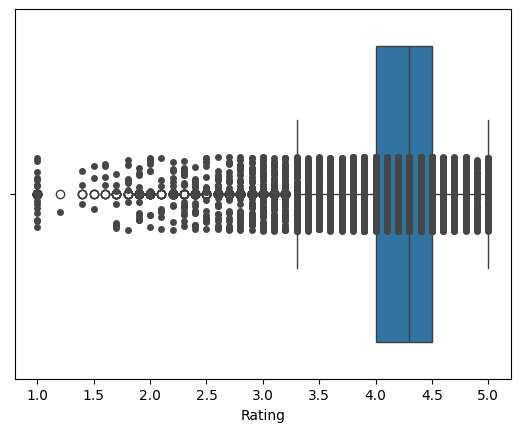

In [307]:
# Note: Boxplots identify outliers based on (IQR)
# A valid value like Rating 2.0 might be considered as an outlier if the average is 4.2,
# even if it appears multiple times
# so Outlier does not necessarily mean 'Error' or 'Invalid Data'.
# It just means the value is rare compared to the majority.
# so we dont delete these outliers unless they are logically impossible
# (e.g., 4.5 <= Rating <= 5 or 1 < Rating <= 3.3 ). Rare values but are real data points
import seaborn as sns
sns.boxplot(x='Rating', data=df)
sns.stripplot(x='Rating', data=df, color="#474646")

<Axes: xlabel='Size'>

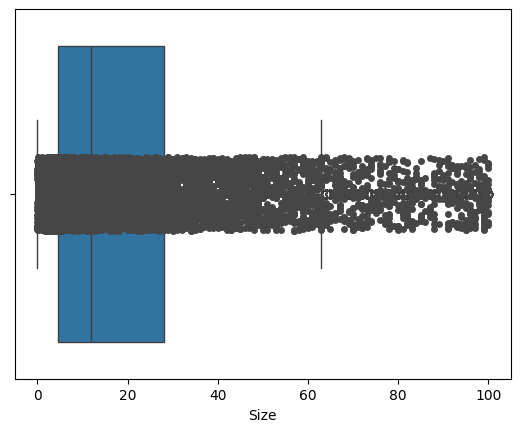

In [308]:
# Size < 0  --> considered outliers and they are              --> no such values 
# size > 55 --> considered outliers but actually they are not --> many values
sns.boxplot(x='Size', data=df)
sns.stripplot(x='Size', data=df, color="#474646")

### **step 4: fixing remaining columns**

In [309]:
# 1. Category 
# replace underscores with space
df['Category'] = df['Category'].str.replace('_', ' ').str.strip()

In [310]:
# 2. Content Rating
# Define the mapping dictionary to handle rare categories
map = {'Adults only 18+': 'Mature 17+',  'Unrated': 'Everyone'}
# 3. Apply the mapping to the column
df['Content Rating'] = df['Content Rating'].replace(map)
df['Content Rating'].value_counts()

Content Rating
Everyone        7906
Teen            1036
Mature 17+       396
Everyone 10+     322
Name: count, dtype: int64

In [311]:
# 4. Genres
# note Education cantains 510
# in phase 2 we detected this redunduncy Education;Education (36) &  Educational;Education (38)
# map Education;Education    --> Education
# map Educational;Education  --> Education
# & add their count to Education 549+50+41
df["Genres"].value_counts(dropna=False)


Genres
Tools                          827
Entertainment                  561
Education                      510
Business                       420
Medical                        395
                              ... 
Role Playing;Brain Games         1
Lifestyle;Pretend Play           1
Music & Audio;Music & Video      1
Strategy;Creativity              1
Role Playing;Education           1
Name: count, Length: 120, dtype: int64

In [312]:
# replace underscores with space
df['Genres'] = df['Genres'].str.replace('_', ' ').str.strip()

In [313]:
# this function checks for exact redundancy within a genre cell.
# it splits the cell by ';', trims spaces, converts to lowercase,
# and returns True if any part is repeated exactly like 'Education;Education'
# returns False for unique or non-redundant combinations like 'Educational;Education'
def has_redundancy(genre):
    if pd.isna(genre): 
        return False
    parts = genre.split(';')
    clean_parts = [p.strip().lower() for p in parts]
    return len(parts) != len(set(clean_parts))

In [314]:
# 36 redundunt value
# the redundancy check confirms that only "Education;Education" (36 rows) exists as exact duplicates in the 'Genres' column. 
# No other exact duplicate were found.
redundant_count = df['Genres'].apply(has_redundancy).sum()
redundant_count

np.int64(36)

In [315]:
# fix only specific redundancy cases (not all Education-related rows)

df['Genres'] = df['Genres'].replace({
    'Education;Education': 'Education',   # --> count Education;Education   = 36
    'Educational;Education': 'Education', # --> count Educational;Education = 38
    'Educational': 'Education'            # --> count Educational           = 37
})

In [316]:
# Education count should be 510+(36+38+37) = 621 (checked)
# note as found now Education count is 621
df["Genres"].value_counts(dropna=False)

Genres
Tools                          827
Education                      621
Entertainment                  561
Business                       420
Medical                        395
                              ... 
Role Playing;Brain Games         1
Lifestyle;Pretend Play           1
Music & Audio;Music & Video      1
Strategy;Creativity              1
Role Playing;Education           1
Name: count, Length: 117, dtype: int64

In [317]:
# "Education;Education" no such category exists anymore
df[df["Genres"]=="Education;Education"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [318]:
# "Educational;Education" no such category exists anymore
df[df["Genres"]=="Educational;Education"]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [319]:
# Current Ver
# Keep the column with minimal cleaning to avoid losing any original information.
# Later, a cleaned version of 'Current Ver' will be extracted for analysis.
# For now, just remove commas from the version numbers to standardize the format.
df["Current Ver"] = df["Current Ver"].str.replace(',', '')

In [320]:
df[df["Current Ver"].str.contains(',')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [321]:
# Android Ver
# Keep the column with minimal cleaning to avoid losing any original information.
# Later, a cleaned version of 'Android Ver' will be extracted for analysis.

In [322]:
df.isna().sum()

App                  0
Category             1
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               1
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

### **Step 5: Handling Missing Values**

| Column          | Missing Values | Phase | Imputation Method      |
|-----------------|----------------|-------|----------------------|
| **Rating**      |  1,463  | 1     | KNNImputer           |
| **Type**        | 1              | 2     | SimpleImputer        |
| **Current Ver** | 8              | 2     | manual fill 'unknown'       |
| **Android Ver** | 2              | 2     | manual fill 'unknown'        |
| **Size**        | 1,277          | 3     | SimpleImputer        |
| **Genres**      | 1              | 3     | SimpleImputer      |
| **Category**    | 1              |3      | SimpleImputer

In [323]:
# 1. Filling the 'Rating' using KNN Imputer
# i assume apps with similar features (like Installs and Reviews) have similar ratings.
# KNN finds these 'neighbors' to fill missing values better than using the average.
# disadvantage: runtime O(n^2) for KNNImputer
# on our dataset (10k rows), it took 2.8 seconds
# this is reasonable and acceptable given the dataset size
from sklearn.impute import KNNImputer
import numpy as np
# Replace the outlier value 19 with NaN
df['Rating'] = df['Rating'].replace(19, np.nan)
# Create KNN imputer
knn_imputer = KNNImputer(n_neighbors=5)
# Apply KNN imputer to a subset of numeric columns related to 'Rating'
cols = ['Rating', 'Reviews', 'Size', 'Installs']
df[cols] = knn_imputer.fit_transform(df[cols])

In [324]:
df[df["Rating"].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [325]:
# 3. filling 'Type'& 'Genres' & 'Category'
# 'Type' & 'Genres' & 'Category' have few missings --> fill using SimpleImputer with most_frequent strategy
SimpleImputer_cols = [ 'Type','Genres' , 'Category']
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df[SimpleImputer_cols] = imputer.fit_transform(df[SimpleImputer_cols])

In [326]:
# 4. filling 'Current Ver' & 'Android Ver'
# 'Current Ver' & 'Android Ver' have few missings & represent raw string data kept for reference only.
# Since we will extract the numeric features ('Current_Ver_Cleaned', 'Android_Ver_Cleaned') for the model,
# complex imputation strategies are unnecessary and won't affect the model's accuracy.
# Therefore, we will use simple imputation (filling with 'Unknown') to ensure data consistency 
# and avoid potential errors during string operations, as these columns will be dropped before training.
df[['Current Ver', 'Android Ver']] = df[['Current Ver', 'Android Ver']].fillna('Unknown')

In [327]:
# 5. filling 'Size' depending on Category median 
# Reason: App size depends on category.
# Games are large, Tools are small.
# Using the category median ensures we assign a realistic size 
# based on the app's type, rather than a misleading global average.
median_per_category = df.groupby('Category')['Size'].agg(lambda x: x.median())
df['Size'] = df['Size'].fillna(df['Category'].map(median_per_category))
# if there are category with all sizes = na --> cant compute median for this category --> fill na with the meadian of the whole 'Size' col
df['Size'] = df['Size'].fillna(df['Size'].median())

### **step 6: feature engineering**

In [328]:
# 1. 'Year-Released' & 'Month-Released'
# Extract the release year and month from the 'Last Updated' column.
# This creates two new columns:
# - 'Year_Released'  : the year the app was last updated
# - 'Month_Released' : the month the app was last updated
df['Year_Released'] = df['Last Updated'].dt.year
df['Month_Released'] = df['Last Updated'].dt.month

In [329]:
# 2. Current_Ver_Cleaned
# Extract the numeric portion of the 'Current Ver' column to use in analysis 
# Using regex    -->      (\d+(?:\.\d+)?)  
#   - \d+        -->       matches one or more digits
#   - (?:\.\d+)? --> optionally matches a decimal point followed by digits
# Any text without a number like 'Varies with device', 'Final') will result in NaN
df['Current_Ver_Cleaned'] = df['Current Ver'].str.extract(r'(\d+(?:\.\d+)?)')[0]

#Convert the extracted col into numeric type (float)
# Use errors='coerce' so that any value that cannot be converted becomes NaN
df['Current_Ver_Cleaned'] = pd.to_numeric(df['Current_Ver_Cleaned'], errors='coerce')
df[['Current Ver', 'Current_Ver_Cleaned']].head()

,Current Ver,Current_Ver_Cleaned
0,6.5,6.50
1,3.2,3.20
2,1.4,1.40
3,7.1,7.10
4,1.28.1,1.28


In [330]:
# in 'Current_Ver_Cleaned' 
# 'Varies with device' becomes nan (1055 value)
# other non numerical values become nan (17 value)
# 8 nan values in  Current_Ver filled with 'unknown'--> when extracted in 'Current_Ver_Cleaned'  --> 8 nan 
# total nan supposed to be 1080
# total nan found 1080
df['Current_Ver_Cleaned'].isna().sum()

np.int64(1080)

In [331]:
# 3. Android_Ver_Cleaned
# Extract the numeric portion of the 'Android Ver' column to use in analysis 
# Using regex: (\d+(?:\.\d+)?)  
#   - \d+       : matches one or more digits
#   - (?:\.\d+)? : optionally matches a decimal point followed by digits
# Any text without a number like 'Varies with device' will result in NaN
df['Android_Ver_Cleaned'] = df['Android Ver'].str.extract(r'(\d+(?:\.\d+)?)')[0]

# Convert the extracted string numbers into numeric type (float)
# Use errors='coerce' so that any value that cannot be converted becomes NaN
df['Android_Ver_Cleaned'] = pd.to_numeric(df['Android_Ver_Cleaned'], errors='coerce')
df[['Android Ver', 'Android_Ver_Cleaned']].head()

,Android Ver,Android_Ver_Cleaned
0,4.1 and up,4.1
1,2.2 and up,2.2
2,4.3 and up,4.3
3,5.0 and up,5.0
4,5.0 and up,5.0


In [332]:
# 'Varies with device' becomes nan (990 value)
# 3 nan values in  Current_Ver 
# 1 filled when we fixed the row where values were shifted --> (become 4 and up)                        --> not nan 
# 2 filled with 'unknown'                                  --> when extracted in 'Current_Ver_Cleaned'  --> 2 nan 
# total nan supposed to be 992
# total nan found 992
df["Android_Ver_Cleaned"].isna().sum()

np.int64(992)

In [ ]:
# i filled missing values using the median because it is less affected by extreme values.
# since app versions change over time, we grouped the data by 'Year_Released' and filled missing values within each year.
# if a certain year had no available data, we used the overall (global) median as a backup to make sure no missing values remain.
cols_to_fix = ['Current_Ver_Cleaned', 'Android_Ver_Cleaned']
for col in cols_to_fix:
    df[col] = df.groupby('Year_Released')[col].transform(lambda x: x.fillna(x.median()))
    global_median = df[col].median()
    df[col].fillna(global_median, inplace=True)

NameError: name 'df' is not defined

In [334]:
# 4. Extract the major version from Current_Ver_Cleaned & Android_Ver_Cleaned
# take only the main version number from 'Current_Ver_Cleaned' and 'Android_Ver_Cleaned'.
# this helps the model by giving simpler numbers and removing small details that aren't important,
# so it can learn patterns more easily from the versions.
df['Version_Major'] = df['Current_Ver_Cleaned'].apply(int)
df['Android_Ver_Major'] = df['Android_Ver_Cleaned'].apply(int)

In [335]:
# 5. Estimated_Revenue 
# Estimate revenue for apps gives approximate estimated earnings
# Multiply Price * Installs * percentage (0.3 here) to estimate revenue
# We assume 30% conversion or revenue factor
df['Estimated_Revenue'] = df['Price'] * df['Installs'] * 0.3
# Display the result
df[['Price',  'Installs',  'Estimated_Revenue']].head(10)

,Price,Installs,Estimated_Revenue
0,0.0,1000000.0,0.0
1,0.0,100000.0,0.0
2,0.0,1000000.0,0.0
3,0.0,1000000.0,0.0
4,0.0,500000.0,0.0
5,0.0,100000.0,0.0
6,0.0,1000000.0,0.0
7,0.0,50000.0,0.0
8,0.0,10000000.0,0.0
9,0.0,100000.0,0.0


In [336]:
df["Estimated_Revenue"].dtype

dtype('float64')

In [337]:
# outliers handling :
# min: 0 , max: 20,970,000
# mean: 145,736 , median: 1,797
# std 1.169463e+06
# big gap btw min, max and mean, median 
# the huge numbers are normal
# no handling stertege 
# only scaling --> Robust scaling
df['Estimated_Revenue'].describe()

count    9.660000e+03
mean     9.041878e+03
std      2.614836e+05
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.097000e+07
Name: Estimated_Revenue, dtype: float64

In [338]:
# no nan values found 
df["Estimated_Revenue"].isna().sum()

np.int64(0)

In [339]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9660 entries, 0 to 9659
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   App                  9660 non-null   str           
 1   Category             9660 non-null   str           
 2   Rating               9660 non-null   float64       
 3   Reviews              9660 non-null   float64       
 4   Size                 9660 non-null   float64       
 5   Installs             9660 non-null   float64       
 6   Type                 9660 non-null   str           
 7   Price                9660 non-null   float64       
 8   Content Rating       9660 non-null   str           
 9   Genres               9660 non-null   str           
 10  Last Updated         9660 non-null   datetime64[us]
 11  Current Ver          9660 non-null   str           
 12  Android Ver          9660 non-null   str           
 13  Year_Released        9660 non-null   int32  

In [340]:
# Reviews & Installs are int not float
df['Reviews'] = df['Reviews'].astype('int64')
df['Installs'] = df['Installs'].astype('int64')

# **Phase 4: Analytical Questions**

in this phase, i will analyze the cleaned data to answer specific business questions.  

**What was done:**
- **Statistical Analysis:** Calculated metrics such as the most expensive app, average sizes, and total revenue.  
- **Visualizations:** Created charts (Bar plots, Heatmaps) to visualize trends and make the data easier to understand.  
- **Insights:** Derived conclusions about user behavior, app categories, and pricing strategies.

#### 1. What is the most expensive app on the Play Store?

In [341]:
# 1. Find the max price in the dataset
max_price = df['Price'].max()
# 2. Filter the dataset to get the apps with this max price
most_expensive_app = df[df['Price'] == max_price]
# 3. Display the result 
most_expensive_app
# only 1 app displayed "I'm Rich - Trump Edition"

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year_Released,Month_Released,Current_Ver_Cleaned,Android_Ver_Cleaned,Version_Major,Android_Ver_Major,Estimated_Revenue
4951,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7.3,10000,Paid,400.0,Everyone,Lifestyle,2018-05-03,1.0.1,4.1 and up,2018,5,1.0,4.1,1,4,1200000.0


In [342]:
# note the top expensive app contains "I am Rich".
# This is joke app and does not offer real functionality.
# it represents extreme price outliers in the dataset.
# this justifies why i will use RobustScaler in the next phase in scaling the Price column

#### 2. Which genre has the highest number of apps? 

In [343]:
# Count the frequency of each genre (including missing values) and display the top ones
count_genre =df["Genres"].value_counts(dropna=False).head()
count_genre

Genres
Tools            828
Education        621
Entertainment    561
Business         420
Medical          395
Name: count, dtype: int64

In [344]:
# note tools is the most common genre
# this shows that developers prefer making useful apps, likely because people need them the most.

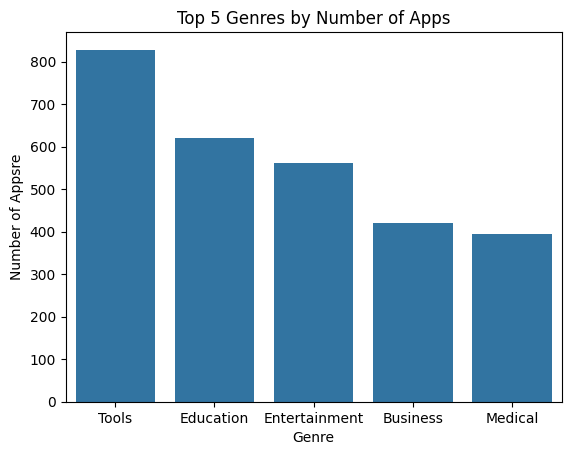

In [345]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
top_5_genres = count_genre
plt.figure()
sns.barplot(x=top_5_genres.index , y=top_5_genres.values)
plt.title('Top 5 Genres by Number of Apps')
plt.xlabel('Genre')
plt.ylabel('Number of Appsre')
plt.show()

#### 3. What is the average size of free vs. paid apps?

In [346]:
# Calculate the average app size for each Type (Free vs Paid)
avg_size = df.groupby("Type")["Size"].mean()
avg_size

Type
Free    21.624775
Paid    19.261052
Name: Size, dtype: float64

In [347]:
# note free apps are larger on average than Paid apps.
# Reason: This is likely because free apps include ads, which increase their file size.

C:\Users\Dema\AppData\Local\Temp\ipykernel_15112\1727800479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_size.index, y=avg_size.values, palette='Set2')


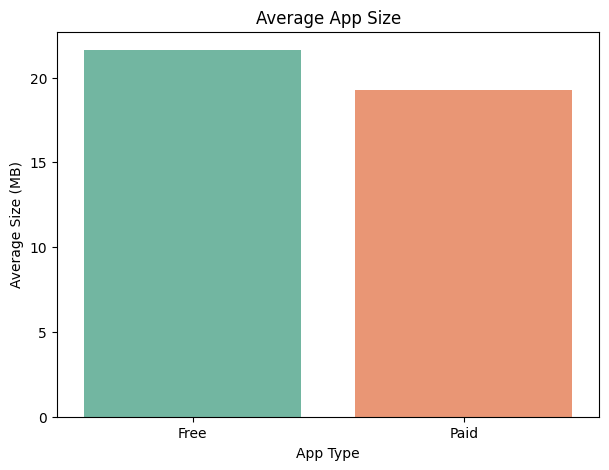

In [348]:
# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))
sns.barplot(x=avg_size.index, y=avg_size.values, palette='Set2')
plt.title('Average App Size')
plt.xlabel('App Type')
plt.ylabel('Average Size (MB)')
plt.show()

#### 4. What are the top 5 most expensive apps with a perfect rating (5)?

In [349]:
# Filter for 5-perfect apps and show the top 5 most expensive ones.
perfect_apps = df[df["Rating"] == 5 ]
top_5_expensive_perfect = perfect_apps.sort_values(by="Price", ascending=False).head(5)
top_5_expensive_perfect.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Year_Released,Month_Released,Current_Ver_Cleaned,Android_Ver_Cleaned,Version_Major,Android_Ver_Major,Estimated_Revenue
9477,Eu Sou Rico,FINANCE,5.0,0,1.4,0,Paid,394.99,Everyone,Finance,2018-07-11,1.0,4.0.3 and up,2018,7,1.0,4.0,1,4,0.000
9577,EP Cook Book,MEDICAL,5.0,0,3.2,0,Paid,200.00,Everyone,Medical,2015-07-26,1.0,3.0 and up,2015,7,1.0,3.0,1,3,0.000
9308,cronometra-br,PRODUCTIVITY,5.0,0,5.4,0,Paid,154.99,Everyone,Productivity,2017-11-24,1.0.0,4.1 and up,2017,11,1.0,4.1,1,4,0.000
9371,BP Fitness Lead Scanner,EVENTS,5.0,0,6.7,1,Paid,109.99,Everyone,Events,2017-08-23,0.0.1,4.1 and up,2017,8,0.0,4.1,0,4,32.997
9445,Eu sou Rico,FINANCE,5.0,0,2.6,0,Paid,30.99,Everyone,Finance,2018-01-09,1.0,4.0 and up,2018,1,1.0,4.0,1,4,0.000


In [350]:
# note the most expensive app is "Eu Sou Rico" at $395. These are professional apps (like Finance and Medical), 
# which justifies the high cost. They are small and have almost no users or reviews. 
# This makes it easy for them to maintain a perfect 5.0 rating.

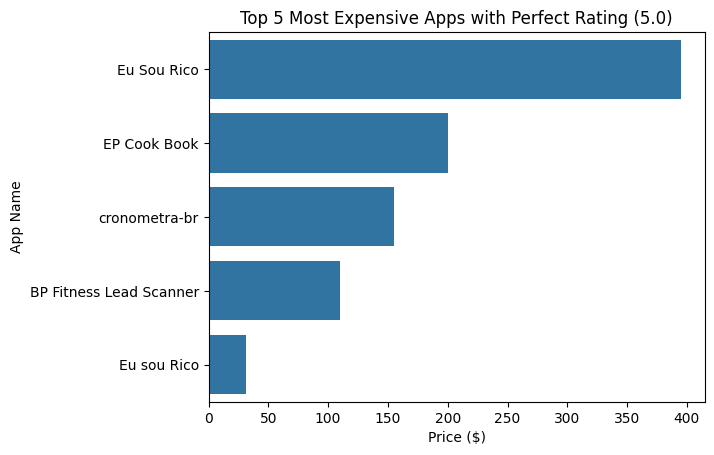

In [351]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.barplot(x='Price', y='App', data=top_5_expensive_perfect)
plt.title('Top 5 Most Expensive Apps with Perfect Rating (5.0)')
plt.xlabel('Price ($)')
plt.ylabel('App Name')
plt.show()

#### 5. How many apps have received more than 50,000 reviews?

In [352]:
# Counts how many apps have more than 50,000 reviews
most_reviews = df[df["Reviews"]>50000]
len(most_reviews)

1944

In [353]:
# note only about 20% of apps have more than 50,000 reviews.
# this shows that most apps don't get this many reviews.

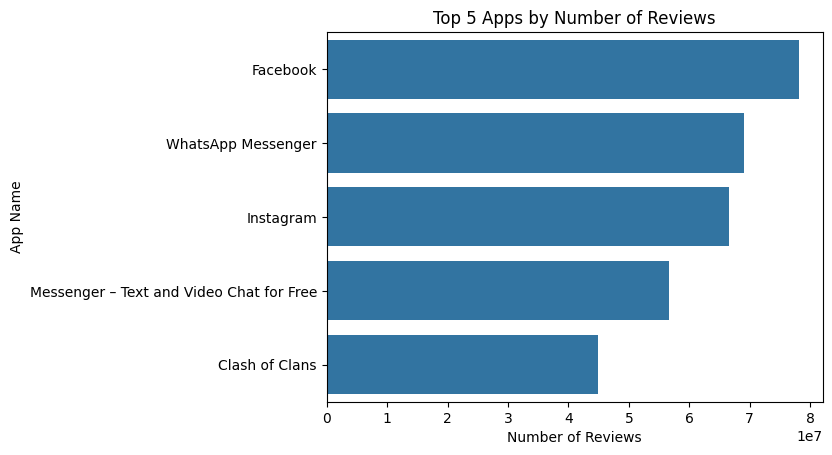

In [354]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
top_5_reviews = df.sort_values('Reviews', ascending=False).head(5)
plt.figure()
sns.barplot(x='Reviews', y='App', data=top_5_reviews)
plt.title('Top 5 Apps by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('App Name')
plt.show()

#### 6. What is the average price of apps grouped by genre and number of installs?

In [355]:
# xalculate the avg price of paid apps grouped by Genre and number of Installs
df_paid = df[df['Type'] == 'Paid']
df_paid.groupby(["Genres","Installs"])["Price"].mean()

Genres   Installs
Action   50          1.990000
         100         2.740000
         1000        1.490000
         10000       5.990000
         50000       2.990000
                       ...   
Weather  500         2.490000
         1000        6.990000
         10000       2.990000
         100000      3.823333
         500000      5.990000
Name: Price, Length: 300, dtype: float64

In [356]:
# note Prices heavely depends on the genre and install count.
# having more installs does not always mean the app has a higher price.
# why?
# free apps usually get the most downloads, so high install counts often mean a price of 0.
# expensive apps are often for specific jobs, so fewer people buy them.

#### 7. How many apps have a rating higher than 4.7, and what is their average price?

In [357]:
# Counts how many apps have a high rating above 4.7
df_Rating= df[df["Rating"] > 4.7 ]
len(df_Rating)

867

In [358]:
# Calculates the average price of apps with a high rating (> 4.7)
avg_price = df_Rating["Price"].mean()
avg_price

np.float64(1.9773356401384088)

In [359]:
# 869 apps have a rating above 4.7.
# their avg price is about 2$, which shows that high-rated apps are usually cheap.

#### 8. What is Google’s estimated revenue from apps with 5,000,000+ installs?
>(Assume Google takes a 30% commission from paid app sales.)

In [360]:
# Calculates the total estimated revenue of paid apps with at least 5000000 installs
df_paid = df[(df['Type'] == 'Paid') & (df['Installs'] >= 5000000)]
total_revenue = df_paid['Estimated_Revenue'].sum()
total_revenue

np.float64(23940000.0)

In [361]:
# Google's estimated revenue is approximately 23.94 million $.

#### 9. What are the maximum and minimum sizes of free vs. paid apps?

In [362]:
# Shows the largest and smallest app sizes for Free and Paid apps
df.groupby("Type")["Size"].agg(['max', 'min'])

,max,min
Type,,
Free,100.0,0.008301
Paid,100.0,0.013672


In [131]:
# note both Free and Paid apps have the same maximum size (100 MB).
# this means file size is not limited by the payment model. 
# However, Free apps tend to have slightly smaller min size than Paid apps.

#### 10. Is there a correlation between rating, number of reviews, size, and price?

In [132]:
# Calculate the correlation matrix for the specified columns
corr_cols = ['Rating', 'Reviews', 'Size', 'Price']
correlation_matrix = df[corr_cols].corr()

# Display the matrix values
correlation_matrix



,Rating,Reviews,Size,Price
Rating,1.000000,0.049879,0.068652,-0.004970
Reviews,0.049879,1.000000,0.147754,-0.007597
Size,0.068652,0.147754,1.000000,-0.024622
Price,-0.004970,-0.007597,-0.024622,1.000000


In [133]:
# note Rating has a very weak correlation with Price and Size.
# This means that charging more or making a larger app does not guarantee a better rating.
# Reviews also show a weak positive correlation with Rating, meaning popular apps aren't always the highest rated.

# note all correlations are very low (near 0), especially Rating vs Price (-0.005).
# we conclude that A higher price, larger size, or more reviews does not guarantee a better rating.
# The strongest link is between Size and Reviews (0.15), meaning larger apps (like games) tend to get more user interaction.

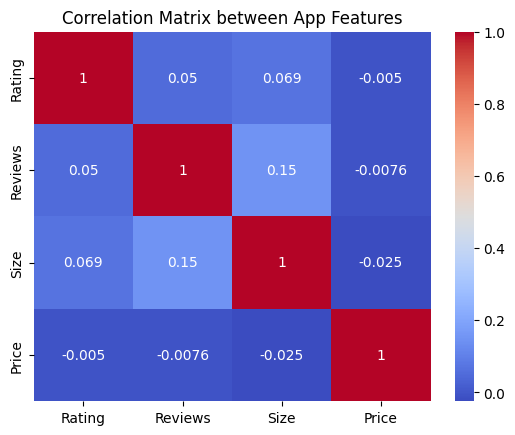

In [134]:
# Visualization:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix between App Features')
plt.show()


#### 11. How many apps exist for each type (Free/Paid) across different content ratings?

In [135]:
# Count the frequency of each combination of Type and Content Rating
df[['Type', 'Content Rating']].value_counts()

Type  Content Rating
Free  Everyone          7251
      Teen               984
Paid  Everyone           655
Free  Mature 17+         378
      Everyone 10+       291
Paid  Teen                52
      Everyone 10+        31
      Mature 17+          18
Name: count, dtype: int64

In [136]:
# note most apps are rated "Everyone", but for Teens and Adults, Free apps are the majority.
# bcz teenagers usually don't have credit cards, developers target them with free apps.
# As a result, paid apps are mostly in the "Everyone" category.

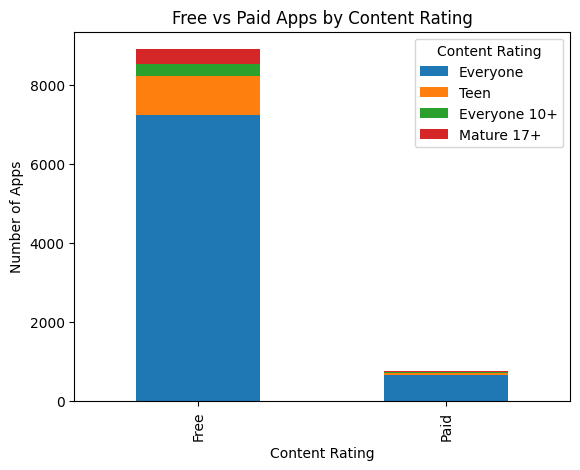

In [137]:
import matplotlib.pyplot as plt
type_rating_counts = df[['Type', 'Content Rating']].value_counts()
plot_data = type_rating_counts.unstack(fill_value=0)
plot_data.plot(kind='bar', stacked=True)
plt.title('Free vs Paid Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.show()

#### 12. How many apps are compatible with Android version 4.x?

In [138]:
# Use the new numeric column for precise filtering
df_android_4x = df[df['Android_Ver_Major'] == 4]
# Count the number of apps having android version with 4.x
len(df_android_4x)

7273

In [ ]:
# note Android 4.x is compatible with the majority of apps 
# this shows that Android 4.x was the most important and popular version for developers.

# **Phase 5: Data Preparation for Modeling**

in this phase, i will prepare the dataset for machine learning.  

**What was done:**
- **Encoding:** Converted categorical text (`Category`, `Genres`, `Type`) into numerical values using **Label Encoding** and **One-Hot Encoding**.  
- **Scaling:** Applied **StandardScaler** and **RobustScaler** to normalize numerical features so they are on the same scale.  
- **Train-Test Split:** Divided the data into **Training (80%)** and **Testing (20%)** sets to evaluate model performance properly.

In [140]:
# Make a copy of the original DataFrame to work on, preserving the original data
df_model = df.copy()
df_model.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Year_Released', 'Month_Released', 'Current_Ver_Cleaned',
       'Android_Ver_Cleaned', 'Version_Major', 'Android_Ver_Major',
       'Estimated_Revenue'],
      dtype='str')

### **Step 1: Defining Target and Features**

#### **Defining the Target Variable (y)**
We select the `Rating` column as the target variable (y) for the ML model.

- **Prediction Objective:** Predict user satisfaction or app quality based on other features.  
- **Exclusion from Features (X):** Removing the target from X prevents **Data Leakage** and ensures valid predictions.

#### **Drop Unnecessary Columns for Feature Set (X)**
We remove columns that are irrelevant or could harm model training:

1. **`App`**          – Unique identifier, not useful for prediction.  
2. **`Last Updated`** – Textual date, replaced with numerical features like Year/Month.  
3. **`Current Ver`**&**`Current_Ver_Cleaned`**  – Text version, replaced with numeric column `Version_Major`
4. **`Android Ver`**&**`Android_Ver_Cleaned`**  – Text version, replaced with numeric column `Android_Ver_Major`.  
5. **`Rating`**       – Target variable; should not be part of X (will be dropped in the splitting step)



In [141]:
cols_to_drop = [
    'App',            
    'Last Updated',    
    'Current Ver',     
    'Android Ver',   
    'Current_Ver_Cleaned',
    'Android_Ver_Cleaned'
]

# Drop these columns to create the feature set
df_model.drop(columns=cols_to_drop, inplace=True)

### **Step 2: Encoding Categorical Features**  

#### **One-Hot Encoding (Few Categories)**
- Columns: `Type`, `Content Rating`  
- Converts categorical text into binary columns (0/1)  
- `drop_first=True` removes one category per column to avoid redundancy  

#### **Label Encoding (Many Categories)**
- Columns: `Category`, `Genres`  
- Converts text into numeric labels (0, 1, 2, …)  
- Original text columns are deleted automatically  

Note:
Categories like Category and Genres are just names with no natural ranking. We still used Label Encoding because using One-Hot Encoding would create hundreds of new columns, making the data too large and complex.

In [142]:
df_model.columns

Index(['Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price',
       'Content Rating', 'Genres', 'Year_Released', 'Month_Released',
       'Version_Major', 'Android_Ver_Major', 'Estimated_Revenue'],
      dtype='str')

In [143]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# 1. Columns with few categories --> One-Hot Encoding
few_categories = ['Type', 'Content Rating']
df_model = pd.get_dummies(df_model, columns=few_categories, drop_first=True)
# drop_first=True removes one category from each column to avoid redundancy

# 2. Columns with many categories--> Label Encoding
many_categories = ['Category', 'Genres']
le = LabelEncoder()
for col in many_categories:
    df_model[col] = le.fit_transform(df_model[col])
    
# Show all columns after encoding
# note the original columns are deleated ['Category', 'Type', 'Content Rating', 'Genres']
df_model.columns

Index(['Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Genres',
       'Year_Released', 'Month_Released', 'Version_Major', 'Android_Ver_Major',
       'Estimated_Revenue', 'Type_Paid', 'Content Rating_Everyone 10+',
       'Content Rating_Mature 17+', 'Content Rating_Teen'],
      dtype='str')

In [144]:
df_model

,Category,Rating,Reviews,Size,Installs,Price,Genres,Year_Released,Month_Released,Version_Major,Android_Ver_Major,Estimated_Revenue,Type_Paid,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen
0,28,4.20,9992,31.000000,1000000,0.00,99,2018,5,6,4,0.000,False,False,False,False
1,29,3.30,999,0.088867,100000,0.00,105,2013,12,3,2,0.000,False,False,False,False
2,26,4.20,9975,18.000000,1000000,0.00,93,2018,1,1,4,0.000,False,False,False,False
3,28,4.00,9971,33.000000,1000000,0.00,99,2018,6,7,5,0.000,False,False,False,False
4,30,4.70,9971,22.000000,500000,0.00,107,2018,8,1,5,0.000,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,11,3.50,0,16.000000,100,0.00,39,2016,6,1,4,0.000,False,False,False,False
9656,3,3.20,0,8.000000,100,0.00,19,2017,7,1,4,0.000,False,False,False,False
9657,17,3.80,0,2.600000,100,0.00,63,2017,12,1,4,0.000,False,False,False,False
9658,23,3.74,0,11.000000,5,0.99,77,2016,8,1,4,1.485,True,False,False,False


### **Step 3: Train-Test Split**

We split the dataset into training and testing sets.

- **Split Ratio:** Use an appropriate split, 80% training and 20% testing.  
- **Random State:** Set a `random_state` to ensure reproducibility of results.  
- **Target Variable:** Clearly define the target variable (y) for the split.

> This ensures the model is tested on **unseen data** for a more accurate estimate of its performance.

In [145]:
# split the dataset into training and testing sets (80% train, 20% test)
# X contains features, y contains the target variable T=Rating
from sklearn.model_selection import train_test_split
X = df_model.drop("Rating", axis=1)
y = df_model["Rating"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)

### **Step 4: Scaling**

**Feature Scaling Approach:**

- For `Year_Released`, `Month_Released`, as there are no obvious outliers and the distributions seem relatively balanced, **StandardScaler** is applied to normalize values (mean = 0, variance = 1).

- For `Size`, `Installs`, `Reviews`, `Price`, `Estimated_Revenue`, due to heavily skewed distributions and the presence of outliers, **RobustScaler** is used.  
  This scaler relies on the median and IQR, making it more resistant to extreme values.

---

### **Notes**

- **No scaling for `Rating` (target variable):**  
  Since `Rating` is the target (y), we do not scale it to keep the predicted values in their original range.

- **No scaling for Version features (`Version_Major`, `Android_Ver_Major`):**  
  These represent ordinal information (e.g., version 4 > version 3), and scaling is not necessary as the numeric meaning is already meaningful and not affected by magnitude differences.

- **No scaling for encoded categorical features:**  
  Columns that were transformed using **One-Hot Encoding** or **Label Encoding** represent categories, not continuous values.  
  Scaling them would distort their meaning and is therefore avoided.

In [146]:
from sklearn.preprocessing import StandardScaler
numeric_cols = ['Year_Released', 'Month_Released'] 
# Initialize StandardScaler
scaler = StandardScaler()
# fit the scaler on training data and transform the training set
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
# transform the test set using the same scaler
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [147]:
from sklearn.preprocessing import RobustScaler
numeric_cols = ['Size', 'Installs', 'Reviews', 'Price' , 'Estimated_Revenue'] 
# Initialize RobustScaler
scaler = RobustScaler(quantile_range=(25.0, 75.0))  # Uses median and IQR to scale values
# Scale the 'Diff' column 
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])

In [148]:
df_model

,Category,Rating,Reviews,Size,Installs,Price,Genres,Year_Released,Month_Released,Version_Major,Android_Ver_Major,Estimated_Revenue,Type_Paid,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen
0,28,4.20,9992,31.000000,1000000,0.00,99,2018,5,6,4,0.000,False,False,False,False
1,29,3.30,999,0.088867,100000,0.00,105,2013,12,3,2,0.000,False,False,False,False
2,26,4.20,9975,18.000000,1000000,0.00,93,2018,1,1,4,0.000,False,False,False,False
3,28,4.00,9971,33.000000,1000000,0.00,99,2018,6,7,5,0.000,False,False,False,False
4,30,4.70,9971,22.000000,500000,0.00,107,2018,8,1,5,0.000,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,11,3.50,0,16.000000,100,0.00,39,2016,6,1,4,0.000,False,False,False,False
9656,3,3.20,0,8.000000,100,0.00,19,2017,7,1,4,0.000,False,False,False,False
9657,17,3.80,0,2.600000,100,0.00,63,2017,12,1,4,0.000,False,False,False,False
9658,23,3.74,0,11.000000,5,0.99,77,2016,8,1,4,1.485,True,False,False,False


In [149]:
cols_to_convert = ['Type_Paid', 'Content Rating_Everyone 10+', 
                   'Content Rating_Mature 17+', 'Content Rating_Teen']

df_model[cols_to_convert] = df_model[cols_to_convert].astype(int)

In [150]:
df_model

,Category,Rating,Reviews,Size,Installs,Price,Genres,Year_Released,Month_Released,Version_Major,Android_Ver_Major,Estimated_Revenue,Type_Paid,Content Rating_Everyone 10+,Content Rating_Mature 17+,Content Rating_Teen
0,28,4.20,9992,31.000000,1000000,0.00,99,2018,5,6,4,0.000,0,0,0,0
1,29,3.30,999,0.088867,100000,0.00,105,2013,12,3,2,0.000,0,0,0,0
2,26,4.20,9975,18.000000,1000000,0.00,93,2018,1,1,4,0.000,0,0,0,0
3,28,4.00,9971,33.000000,1000000,0.00,99,2018,6,7,5,0.000,0,0,0,0
4,30,4.70,9971,22.000000,500000,0.00,107,2018,8,1,5,0.000,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9655,11,3.50,0,16.000000,100,0.00,39,2016,6,1,4,0.000,0,0,0,0
9656,3,3.20,0,8.000000,100,0.00,19,2017,7,1,4,0.000,0,0,0,0
9657,17,3.80,0,2.600000,100,0.00,63,2017,12,1,4,0.000,0,0,0,0
9658,23,3.74,0,11.000000,5,0.99,77,2016,8,1,4,1.485,1,0,0,0
